In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !pip install --upgrade certifi

In [3]:
# !pip install gtts pydub audioop-lts
# !pip install --upgrade certifi # added certifi-2025.10.5, though check https://api.msedgeservices.com
import time
import os
import pandas as pd
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont
from moviepy import ImageClip
from utils_data import (
    load_raw_data, check_dups, filter_df_to_vocab_of_interest, 
    fill_default_settings, delete_previous_attempt_files
    )
from utils_video import (
    combine_clips_with_audio_to_create_video, create_icon_from_slide,
    draw_word_index, draw_logo, draw_previous_word, draw_previous_sent,
    draw_vocab_based_on_format, generate_intro_slide,
    generate_word_list_slide, generate_outro_slide,
    fill_default_video_configs
)
from utils_audio import (
    create_tts_files_for_one_vocab_word, compute_pinyin_and_create_recordings,
    combine_audio_files_and_compute_durations,
    generate_nonvocab_audio_and_compute_durations, create_final_audio_from_each_word_and_nonvocab
)
hanzi_font_path = '/System/Library/Fonts/STHeiti Medium.ttc'
pd.options.display.max_columns = 100
pd.options.display.max_rows = 130

In [4]:
# reload configs
from configs.v056_2026apr import (
    data_settings, output_path,
    video_configs,
    nonvocab_slides, subtitle_text_configs,
    DEFAULT_TEXT_PROPERTIES,
)
if subtitle_text_configs is not None:
    subtitle_text_configs['font'] = ImageFont.truetype(subtitle_text_configs['font_name'], subtitle_text_configs['font_size'])

In [5]:
truly_load_data = False
to_delete = False

# 0. Create dataframe of settings

In [6]:
# Fill in default data settings
data_settings = fill_default_settings(data_settings)

# Fill in default video configs
video_configs = fill_default_video_configs(video_configs)

# Create folder for non-audio recordings for this project
project_artifacts_folder = f"{output_path}{data_settings['recording_name']}"
data_settings['audio_path'] = f"{project_artifacts_folder}/audio_{data_settings['filename_suffix']}.mp3"
data_settings['video_path'] = f"{project_artifacts_folder}/video_{data_settings['filename_suffix']}.mp4"

# Create folder if not exists, and delete previous files if desired
if not os.path.exists(project_artifacts_folder):
    os.mkdir(project_artifacts_folder)
if to_delete:
    delete_previous_attempt_files(project_artifacts_folder, data_settings)

# Create folders for audio tts
voice_name_keys = ['voice_name_zh', 'voice_name_en', 'voice_name_convo']
for vnk in voice_name_keys:
    if vnk in data_settings:
        if isinstance(data_settings[vnk], dict):
            for speaker, voice_name in data_settings[vnk].items():
                tts_path = f"output/tts/{voice_name}"
                if not os.path.exists(tts_path):
                    os.mkdir(tts_path)
        else:
            voice_name = data_settings[vnk]
            tts_path = f"output/tts/{voice_name}"
            if not os.path.exists(tts_path):
                os.mkdir(tts_path)

data_settings

{'recording_id': 'ce_csent',
 'silent_components': True,
 'filename_suffix': '2026apr_words',
 'types_allowed': ['word',
  'prefix',
  'suffix',
  'abbreviation',
  'multi_word',
  'verb_ending',
  'phrase',
  'speak_phrase',
  'saying',
  'idiom',
  'modal particle',
  'proper noun'],
 'max_priority': 7,
 'min_known_english_prompt': 2,
 'min_date': '2026-04-01',
 'max_date': '2026-05-01',
 'min_priority': 1,
 'max_known_english_prompt': 6,
 'min_known_pinyin_prompt': 1,
 'max_known_pinyin_prompt': 6,
 'sort_keys': ['cat_v3',
  'cat2_v3',
  'cat3_v3',
  'category1',
  'category2',
  'pinyin'],
 'sort_asc': [True, True, True, True, True, True],
 'min_combo_quality': 10,
 'categories_allowed': None,
 'categories_not_allowed': None,
 'categories2_allowed': None,
 'categories2_not_allowed': None,
 'cat_v3_allowed': None,
 'cat_v3_not_allowed': None,
 'cat2_v3_allowed': None,
 'cat2_v3_not_allowed': None,
 'source1_values_allowed': None,
 'types_allowed_str': '',
 'min_adu': 3,
 'min_per': 

# 1. Load data

In [7]:
if truly_load_data:
    df_all_vocab = load_raw_data()
    df_all_vocab.to_csv('static/latest_data.csv', index=False)
else:
    df_all_vocab = pd.read_csv('static/latest_data.csv')
    print('!!!!!!!! WARNING: not truly loading data !!!!!!!!')

df_dups = check_dups(df_all_vocab)
print(df_all_vocab.shape)
df_all_vocab.head(3)

!!!!!!!! WARNING: not truly loading data !!!!!!!!
(8218, 39)


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,idiom_literal,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,1,房贷,fáng dài,mortgage,word,1.0,life,NaN,Finance & Economy,NaN,借贷与负债,MISSING,1.0,1.0,2.0,1.0,房子,house,贷款,loan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,他每个月都要还房贷,Ta měi gè yuè dōu yào huán fángdài,He has to pay his mortgage every month,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
1,2,白天,bái tiān,daytime,word,2.0,time,NaN,Time,NaN,时间段 / 时长,1.0,2.0,1.0,1.0,1.0,白,white,天,day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,白天很热晚上比较凉快,Báitiān hěn rè wǎnshàng bǐjiào liángkuai,It is hot in the daytime and cooler at night,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
2,3,组成,zǔ chéng,to form;make up,word,3.0,general,NaN,Language & Expression,NaN,逻辑与结构,MISSING,5.0,5.0,5.0,3.0,组,set,成,become,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,水是由氢和氧组成的,Shuǐ shì yóu qīng hé yǎng zǔchéng de,Water is made up of hydrogen and oxygen,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN


In [8]:
print(f'# duplicate vocab: {len(df_dups)}')
df_dups

# duplicate vocab: 0


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,idiom_literal,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic


# 2. Select data

In [9]:
df_vocab_lists = filter_df_to_vocab_of_interest(df_all_vocab, data_settings)
n_vocab = len(df_vocab_lists)
print(data_settings['recording_name'], n_vocab)
df_vocab_lists.head(3)

0509_ce_csent_2026apr_words 211


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,idiom_literal,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,8139,拆除,chāi chú,demolish;tear down,word,4.0,NaN,NaN,Architecture & Infrastructure,NaN,NaN,MISSING,5.0,5.0,5.0,5.0,拆,to tear open,消除,to eliminate,NaN,NaN,NaN,NaN,NaN,NaN,拆: to tear open\n消除: to eliminate,NaN,旧楼已经被拆除了。,jiù lóu yǐ jīng bèi chāi chú le,The old building has been demolished.,2026-04-28,daily add,NaN,NaN,5.0,5.0,5.0,NaN
1,8261,楼群,lóu qún,building complex,word,4.0,NaN,NaN,Architecture & Infrastructure,NaN,NaN,MISSING,5.0,5.0,5.0,3.0,大楼,building,群体,group,NaN,NaN,NaN,NaN,NaN,NaN,大楼: building\n群体: group,NaN,这里是高楼群。,zhè lǐ shì gāo lóu qún,This area has many tall buildings.,2026-04-28,daily add,NaN,NaN,5.0,5.0,5.0,NaN
2,8252,栅栏,zhà lán,fence,word,4.0,NaN,NaN,Architecture & Infrastructure,NaN,NaN,MISSING,5.0,5.0,5.0,6.0,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,修好栅栏。,xiū hǎo zhà lán,Fix the fence.,2026-04-28,daily add,NaN,NaN,5.0,5.0,5.0,NaN


# 3. Create vocabulary audio recordings

In [10]:
# # one-off
# from edge_tts import Communicate
# communicate = Communicate("Help", 'en-US-MichelleNeural')
# communicate.save_sync('tmp2.mp3')

In [11]:
# os.remove('output/tts/zh-CN-XiaoyuMultilingualNeural/今天下雨记得带雨衣.mp3')
if data_settings['recording_id'] == '005':
    df_vocab_lists = compute_pinyin_and_create_recordings(df_vocab_lists)

start_time = time.time()
for i_row, row in df_vocab_lists.iterrows():
    print(f"{(time.time()-start_time):.1f}s, row{i_row}")
    create_tts_files_for_one_vocab_word(row, data_settings)

0.0s, row0
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 拆除
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, demolish;tear down
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 旧楼已经被拆除了。
0.0s, row1
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 楼群
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, building complex
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 这里是高楼群。
0.0s, row2
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 栅栏
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, fence
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 修好栅栏。
0.0s, row3
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 补差价
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, price matching;pay the difference
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 你需要补差价。
0.0s, row4
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 饥饿营销
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, hunger marketing
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 这家公司常用饥饿营销。
0.0s, row5
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 连锁品牌
0.0

## 3b. Compute durations of combined audios for each vocab word

In [12]:
# os.remove('output/tts/zh-CN-XiaoxiaoNeural/蛇是典型的爬行动物。.mp3')

In [13]:
audio_duration_file_name = f"{project_artifacts_folder}/audio_durations_vocab_only.csv"
if os.path.exists(audio_duration_file_name):
    df_vocab_audio_durations = pd.read_csv(audio_duration_file_name)
    print(f"Loaded existing audio durations for {data_settings['recording_name']}, shape {df_vocab_audio_durations.shape}")
else:
    df_vocab_audio_durations = combine_audio_files_and_compute_durations(df_vocab_lists, data_settings)
    df_vocab_audio_durations.to_csv(audio_duration_file_name, index=False)

df_vocab_audio_durations['nonvocab_file_path'] = None
df_vocab_audio_durations['nonvocab_pause_ms'] = None
df_vocab_audio_durations['nonvocab_key'] = None
print(f"Total duration: {df_vocab_audio_durations['combined'].sum()}s")
df_vocab_audio_durations.head(3)

Loaded existing audio durations for 0509_ce_csent_2026apr_words, shape (211, 17)
Total duration: 1553.8720833333332s


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key
0,拆除,chāi chú,demolish;tear down,旧楼已经被拆除了。,jiù lóu yǐ jīng bèi chāi chú le,The old building has been demolished.,5.0,NaN,1.296,2.064,2.184,0.2,1.996,4.560,7.544,7.543583,拆: to tear open\n消除: to eliminate,None,None,None
1,楼群,lóu qún,building complex,这里是高楼群。,zhè lǐ shì gāo lóu qún,This area has many tall buildings.,5.0,NaN,1.248,1.536,1.896,0.2,1.948,3.984,6.680,6.679583,大楼: building\n群体: group,None,None,None
2,栅栏,zhà lán,fence,修好栅栏。,xiū hǎo zhà lán,Fix the fence.,5.0,NaN,1.176,1.104,1.608,0.2,1.876,3.480,5.888,5.887583,NaN,None,None,None


# 4. Create non-vocab audio recordings

In [14]:
df_vocab_audio_durations, audio_filler_variables, nonvocab_slides = generate_nonvocab_audio_and_compute_durations(
    data_settings, df_vocab_audio_durations, nonvocab_slides, project_artifacts_folder)
df_vocab_audio_durations.head()

intro audio already generated: 我的普通话数据库视频 56
outro audio already generated: 如果你有任何问题、建议或反馈，请留言。请点赞并订阅。


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_english,start_sent
0,我的普通话数据库视频 56,wǒ de pǔtōnghuà shùjùkù shìpín 56,My Mandarin Chinese Database Video 56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.620000,NaN,output/videos/0509_ce_csent_2026apr_words/我的普通...,500,intro,3.620000,0.000000,NaN,NaN,NaN
1,拆除,chāi chú,demolish;tear down,旧楼已经被拆除了。,jiù lóu yǐ jīng bèi chāi chú le,The old building has been demolished.,5.0,NaN,1.296,2.064,2.184,0.2,1.996,4.560,7.544,7.543583,拆: to tear open\n消除: to eliminate,None,None,None,11.163583,3.620000,3.820000,5.616000,8.180000
2,楼群,lóu qún,building complex,这里是高楼群。,zhè lǐ shì gāo lóu qún,This area has many tall buildings.,5.0,NaN,1.248,1.536,1.896,0.2,1.948,3.984,6.680,6.679583,大楼: building\n群体: group,None,None,None,17.843167,11.163583,11.363583,13.111583,15.147583
3,栅栏,zhà lán,fence,修好栅栏。,xiū hǎo zhà lán,Fix the fence.,5.0,NaN,1.176,1.104,1.608,0.2,1.876,3.480,5.888,5.887583,NaN,None,None,None,23.730750,17.843167,18.043167,19.719167,21.323167
4,补差价,bǔ chā jià,price matching;pay the difference,你需要补差价。,nǐ xū yào bǔ chā jià。,You need to pay the difference.,5.0,NaN,1.368,2.784,1.752,0.2,2.068,5.352,7.904,7.903583,补充: to supplement\n差别: difference\n价格: price,None,None,None,31.634333,23.730750,23.930750,25.798750,29.082750


# 5. Combine individual vocab into final audio recording

In [15]:
if not os.path.exists(data_settings['audio_path']):
    create_final_audio_from_each_word_and_nonvocab(df_vocab_audio_durations, data_settings)
else:
    print(f"Final audio already exists at {data_settings['audio_path']}")

Final audio already exists at output/videos/0509_ce_csent_2026apr_words/audio_2026apr_words.mp3


# 6. Create images for video

In [16]:
# If don't want to rerun the above cells, then just run this cell to load the audio durations
audio_generation_previous_run = True
if audio_generation_previous_run:
    try:
        df_vocab_audio_durations = pd.read_csv(f"{project_artifacts_folder}/audio_durations_all.csv")
        print(f"{data_settings['recording_name']} loaded")
    except FileNotFoundError:
        print(f"File not found for recording {data_settings['recording_name']}, please run the cell above to generate audio durations.")
df_vocab_audio_durations.head()

0509_ce_csent_2026apr_words loaded


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_english,start_sent
0,我的普通话数据库视频 56,wǒ de pǔtōnghuà shùjùkù shìpín 56,My Mandarin Chinese Database Video 56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.620000,NaN,output/videos/0509_ce_csent_2026apr_words/我的普通...,500.0,intro,3.620000,0.000000,NaN,NaN,NaN
1,拆除,chāi chú,demolish;tear down,旧楼已经被拆除了。,jiù lóu yǐ jīng bèi chāi chú le,The old building has been demolished.,5.0,NaN,1.296,2.064,2.184,0.2,1.996,4.560,7.544,7.543583,拆: to tear open\n消除: to eliminate,NaN,NaN,NaN,11.163583,3.620000,3.820000,5.616000,8.180000
2,楼群,lóu qún,building complex,这里是高楼群。,zhè lǐ shì gāo lóu qún,This area has many tall buildings.,5.0,NaN,1.248,1.536,1.896,0.2,1.948,3.984,6.680,6.679583,大楼: building\n群体: group,NaN,NaN,NaN,17.843167,11.163583,11.363583,13.111583,15.147583
3,栅栏,zhà lán,fence,修好栅栏。,xiū hǎo zhà lán,Fix the fence.,5.0,NaN,1.176,1.104,1.608,0.2,1.876,3.480,5.888,5.887583,NaN,NaN,NaN,NaN,23.730750,17.843167,18.043167,19.719167,21.323167
4,补差价,bǔ chā jià,price matching;pay the difference,你需要补差价。,nǐ xū yào bǔ chā jià。,You need to pay the difference.,5.0,NaN,1.368,2.784,1.752,0.2,2.068,5.352,7.904,7.903583,补充: to supplement\n差别: difference\n价格: price,NaN,NaN,NaN,31.634333,23.730750,23.930750,25.798750,29.082750


## 6a. Vocab words

Drawing 0: 拆除
Drawing 1: 楼群
Drawing 2: 栅栏
Drawing 3: 补差价
Drawing 4: 饥饿营销
Drawing 5: 连锁品牌
Drawing 6: 顺丰
Drawing 7: 申通
Drawing 8: 圆通
Drawing 9: 中通
Drawing 10: 眼罩
Drawing 11: 大道至简
Drawing 12: 君为臣纲，父为子纲、夫为妻纲
reduced font size to 49
reduced font size to 48
reduced font size to 47
reduced font size to 46
reduced font size to 45
reduced font size to 44
reduced font size to 43
reduced font size to 42
reduced font size to 41
reduced font size to 40
reduced font size to 39
reduced font size to 38
reduced font size to 37
reduced font size to 36
reduced font size to 35
reduced font size to 34
reduced font size to 33
reduced font size to 32
reduced font size to 31
Drawing 13: 啃老
Drawing 14: 苦肉计
Drawing 15: 人如其名
Drawing 16: 儒家
Drawing 17: 有多大本事享多大的福
reduced font size to 49
reduced font size to 48
reduced font size to 47
reduced font size to 46
reduced font size to 45
reduced font size to 44
reduced font size to 43
reduced font size to 42
reduced font size to 41
Drawing 18: 子不教父之过
Drawing 19: 降噪耳机
Dr


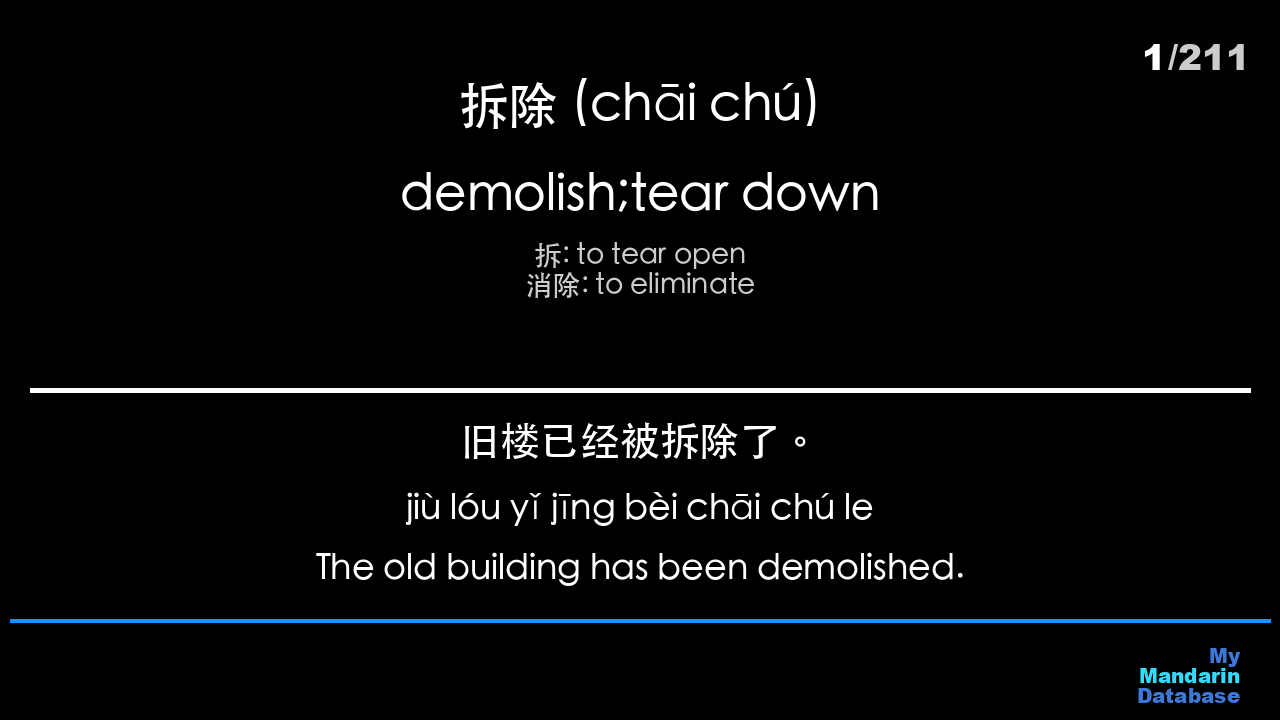

In [17]:
# Overall initializations
clips = []
previous_word = ''
previous_sent = ''

# Create folder to hold slide images
slides_path = f"{project_artifacts_folder}/slides"
if not os.path.exists(slides_path):
    os.mkdir(slides_path)

# Fill in defaults for any missing properties
for config_key, default_config_value in DEFAULT_TEXT_PROPERTIES.items():
    for vocab_slide_id, vocab_slide_settings in video_configs['vocab_slide'].items():
        if config_key not in vocab_slide_settings.keys():
            video_configs['vocab_slide'][vocab_slide_id][config_key] = default_config_value

# Iterate through each word
df_audio_durations_words_only = df_vocab_audio_durations.dropna(subset='sum_theory').reset_index(drop=True)
for word_idx, row in df_audio_durations_words_only.iterrows():
    # if row['chinese'] == '包裹':
    # Initialize image
    print(f'Drawing {word_idx}: {row["chinese"]}')
    current_image_file_path = f"{slides_path}/{row['chinese']}"
    img = Image.new("RGB", video_configs['bg_size'], color=video_configs['bg_color'])
    draw = ImageDraw.Draw(img)
    
    # Header/Footer texts
    draw_word_index(draw, video_configs, n_vocab, word_idx)
    if 'logo' in video_configs.keys():
        draw_logo(draw, video_configs)
    if 'previous_word' in video_configs.keys():
        draw_previous_word(draw, video_configs, previous_word)
    if 'previous_sent' in video_configs.keys():
        draw_previous_sent(draw, video_configs, previous_sent)
    draw.line([
        (video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y']),
        (video_configs['bg_size'][0] - video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y'])],
        fill=video_configs['footer_line']['color'],
        width=video_configs['footer_line']['width'],
        joint=None)
    
    # Update previous
    previous_word = f"{row['chinese']}\n{row['pinyin']}\n{row['english']}"
    if 'previous_sent' in video_configs.keys():
        previous_sent = f"{row['sentence']}\n{row['sentence_pinyin']}\n{row['sentence_english']}"

    # Draw vocab depending on recording ID
    # break
    draw_vocab_based_on_format(data_settings['recording_id'], row, video_configs, current_image_file_path, img, draw, clips)
    # break

my_img = clips[2]
my_img.display_in_notebook()

# 7. Create non-vocab slides


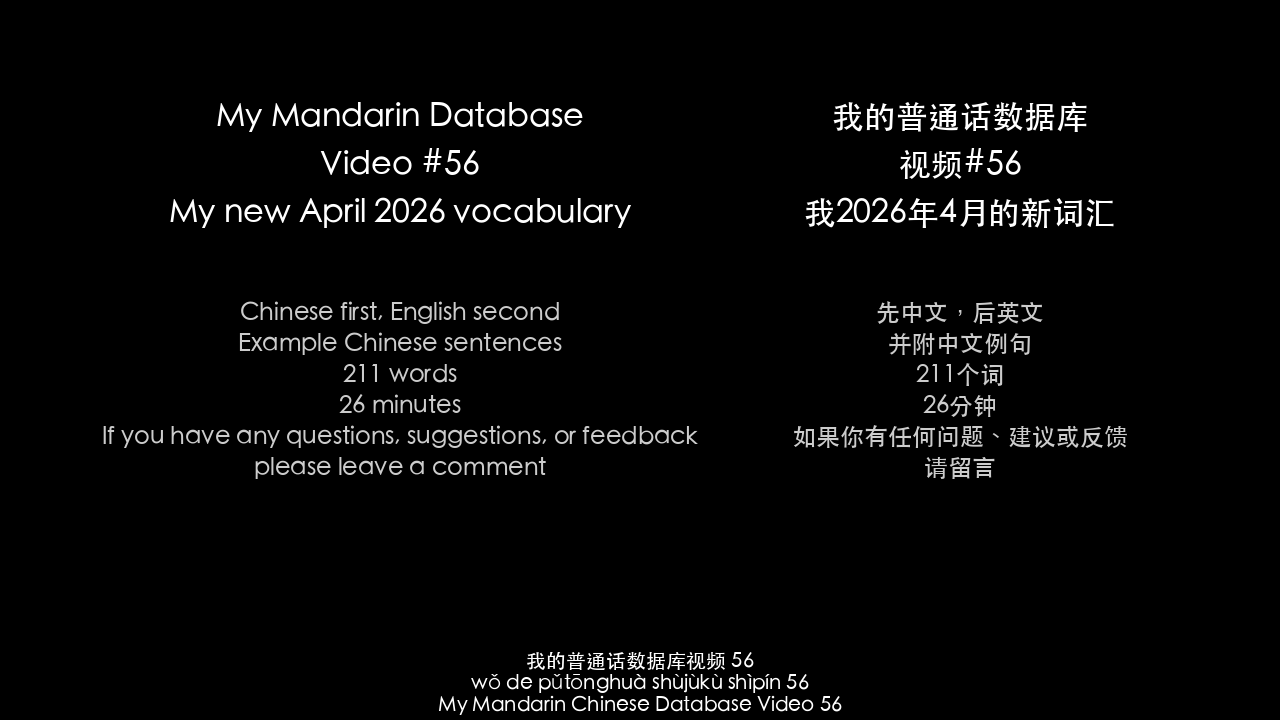

In [18]:
if nonvocab_slides is not None:
    if 'intro' in nonvocab_slides.keys():
        img = generate_intro_slide(video_configs, nonvocab_slides['intro'], subtitle_text_configs, audio_filler_variables)
        img.save(f"{project_artifacts_folder}/intro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/intro.png", duration=1).with_start(0)
my_img.display_in_notebook()


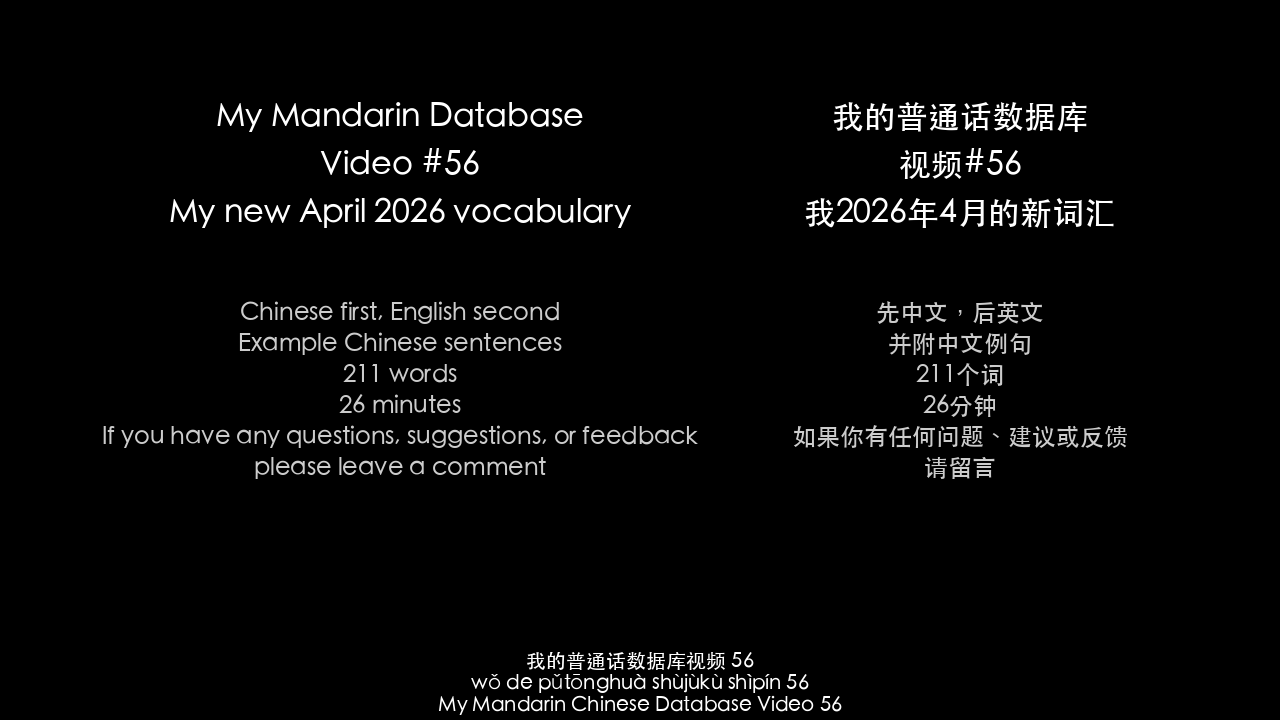

In [19]:
if nonvocab_slides is not None:
    if 'word_list' in nonvocab_slides.keys():
        img = generate_word_list_slide(video_configs, nonvocab_slides['word_list'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/word_list.png")
        my_img = ImageClip(f"{project_artifacts_folder}/word_list.png", duration=1).with_start(0)
my_img.display_in_notebook()

In [20]:
# nonvocab_slides['outro'] = {
#         'chinese': '如果你有任何问题、建议或反馈，请留言。请点赞并订阅。',
#         'pinyin': 'Rúguǒ nǐ yǒu rènhé wèntí, jiànyì huò fǎnkuì, qǐng liúyán. Qǐng diǎn zàn bìng dìngyuè.',
#         'english': 'If you have any questions, suggestions, or feedback, please leave a comment. Please like and subscribe.',
#         'clip_index': -1,
#         'change_index': None,
#         'pause_ms': 500,

#         'y_top': 10,
#         'y_bottom': 70,
#         'x_top': 10,
#         'spacing': 0,
#         'font_size': 14,
#         'fill': '#FFFFFF',
#         'align': 'left',
#         'col_space': 0,
#         'col_space_big': 0,
#         'definition_configs':{
#             'chinese': {'x_offset': 0, 'x_max': 70, 'font_path': hanzi_font_path},
#             'english': {'x_offset': None, 'x_max': 180, 'font_path': hanzi_font_path},
#         }
# }

reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 6
reduced font size to 5
reduced font size to 13
reduced font size to 13
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 13
reduced font size to 12
reduced font size to 13
reduced font size to 12
reduced font size to 11
reduced font size to 10
reduced font size to 9
r


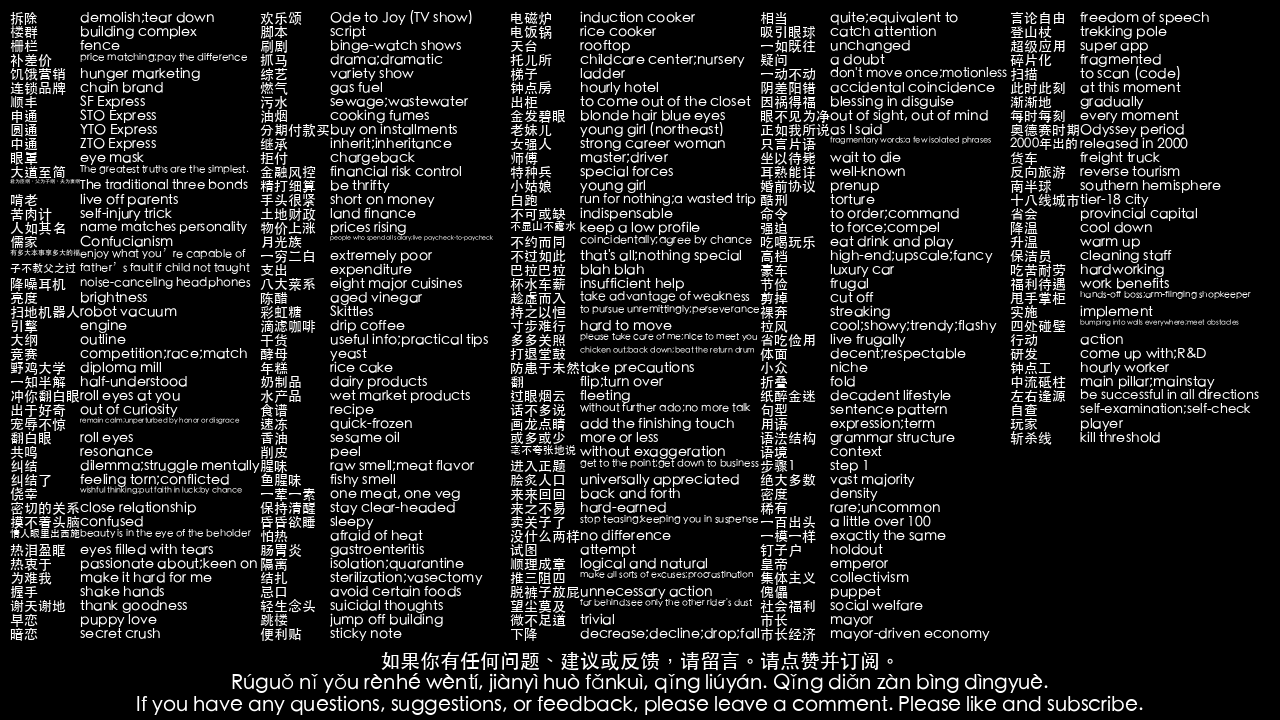

In [21]:
if nonvocab_slides is not None:
    if 'outro' in nonvocab_slides.keys():
        img = generate_outro_slide(video_configs, nonvocab_slides['outro'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/outro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/outro.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 8. Create video icon


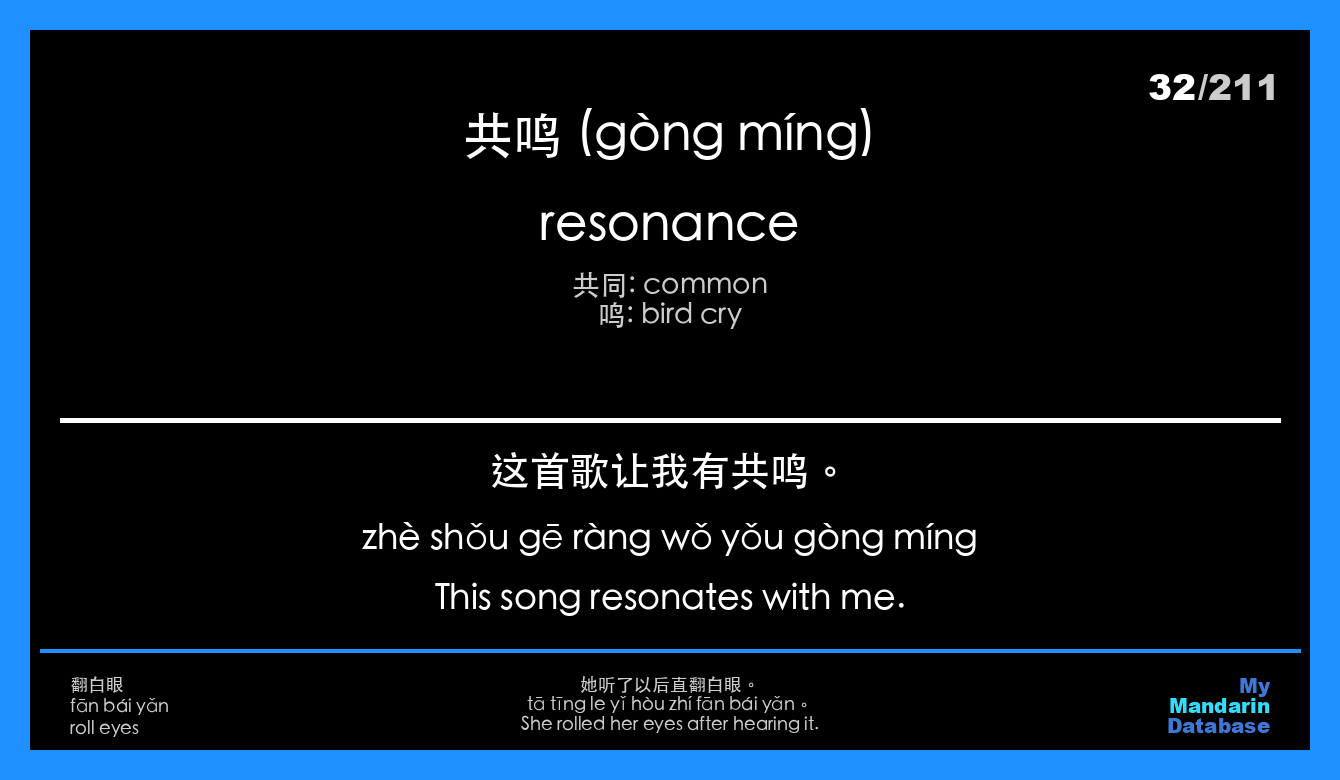

In [22]:
if 'icon_configs' in video_configs.keys():
    img = create_icon_from_slide(video_configs['icon_configs'], video_configs, project_artifacts_folder)
    img.save(f'{project_artifacts_folder}/icon.png')
    my_img = ImageClip(f"{project_artifacts_folder}/icon.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 9. Create video

In [24]:
combine_clips_with_audio_to_create_video(clips, nonvocab_slides, project_artifacts_folder, data_settings)

intro
outro
Number of clips: 635
audio: 1564.180s, video: 1564.112s; difference: 0.068s
MoviePy - Building video output/videos/0509_ce_csent_2026apr_words/video_2026apr_words.mp4.
MoviePy - Writing audio in video_2026apr_wordsTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
MoviePy - Writing video output/videos/0509_ce_csent_2026apr_words/video_2026apr_words.mp4



MoviePy - Done !
MoviePy - video ready output/videos/0509_ce_csent_2026apr_words/video_2026apr_words.mp4
